In [7]:
import requests
import pandas as pd
from datetime import datetime
import time
import os

def fetch_pm25(site_name, lat, lon, years):
    all_data = []

    for year in years:
        for month in range(1, 13):
            start_date = datetime(year, month, 1).strftime("%Y-%m-%d")
            end_date   = datetime(year + 1, 1, 1).strftime("%Y-%m-%d") if month == 12 \
                         else datetime(year, month + 1, 1).strftime("%Y-%m-%d")

            url = "https://air-quality-api.open-meteo.com/v1/air-quality"
            params = {
                "latitude":   lat,
                "longitude":  lon,
                "start_date": start_date,
                "end_date":   end_date,
                "hourly":     "pm2_5",
                "timezone":   "auto"
            }

            print(f"Fetching {site_name} — {start_date} to {end_date}")
            response = requests.get(url, params=params)

            if response.status_code != 200:
                print(f"  Failed. Status: {response.status_code}")
                continue

            data = response.json()
            if "hourly" not in data:
                print(f"  No data.")
                continue

            df = pd.DataFrame(data["hourly"])
            all_data.append(df)
            time.sleep(0.5)

    if all_data:
        final_df = pd.concat(all_data, ignore_index=True)
        final_df.rename(columns={"time": "datetime", "pm2_5": "PM2_5"}, inplace=True)
        final_df["datetime"] = pd.to_datetime(final_df["datetime"])

        os.makedirs("../data/pm25", exist_ok=True)
        out_path = f"../data/pm25/{site_name}_pm25.csv"
        final_df.to_csv(out_path, index=False)
        print(f"Saved: {out_path}  |  shape: {final_df.shape}")
    else:
        print(f"No data collected for {site_name}.")


sites = [
    {"name": "HU_IRB", "lat": 38.9215, "lon": -77.0190},
    {"name": "GSFC",   "lat": 39.029,  "lon": -76.878},
    {"name": "SERC",   "lat": 38.9784, "lon": -76.4922},
]

years = [2021, 2022, 2023, 2024]

for site in sites:
    fetch_pm25(site["name"], site["lat"], site["lon"], years)

Fetching HU_IRB — 2021-01-01 to 2021-02-01
Fetching HU_IRB — 2021-02-01 to 2021-03-01
Fetching HU_IRB — 2021-03-01 to 2021-04-01
Fetching HU_IRB — 2021-04-01 to 2021-05-01
Fetching HU_IRB — 2021-05-01 to 2021-06-01
Fetching HU_IRB — 2021-06-01 to 2021-07-01
Fetching HU_IRB — 2021-07-01 to 2021-08-01
Fetching HU_IRB — 2021-08-01 to 2021-09-01
Fetching HU_IRB — 2021-09-01 to 2021-10-01
Fetching HU_IRB — 2021-10-01 to 2021-11-01
Fetching HU_IRB — 2021-11-01 to 2021-12-01
Fetching HU_IRB — 2021-12-01 to 2022-01-01
Fetching HU_IRB — 2022-01-01 to 2022-02-01
Fetching HU_IRB — 2022-02-01 to 2022-03-01
Fetching HU_IRB — 2022-03-01 to 2022-04-01
Fetching HU_IRB — 2022-04-01 to 2022-05-01
Fetching HU_IRB — 2022-05-01 to 2022-06-01
Fetching HU_IRB — 2022-06-01 to 2022-07-01
Fetching HU_IRB — 2022-07-01 to 2022-08-01
Fetching HU_IRB — 2022-08-01 to 2022-09-01
Fetching HU_IRB — 2022-09-01 to 2022-10-01
Fetching HU_IRB — 2022-10-01 to 2022-11-01
Fetching HU_IRB — 2022-11-01 to 2022-12-01
Fetching HU

ValueError: Missing column provided to 'parse_dates': 'datetime'

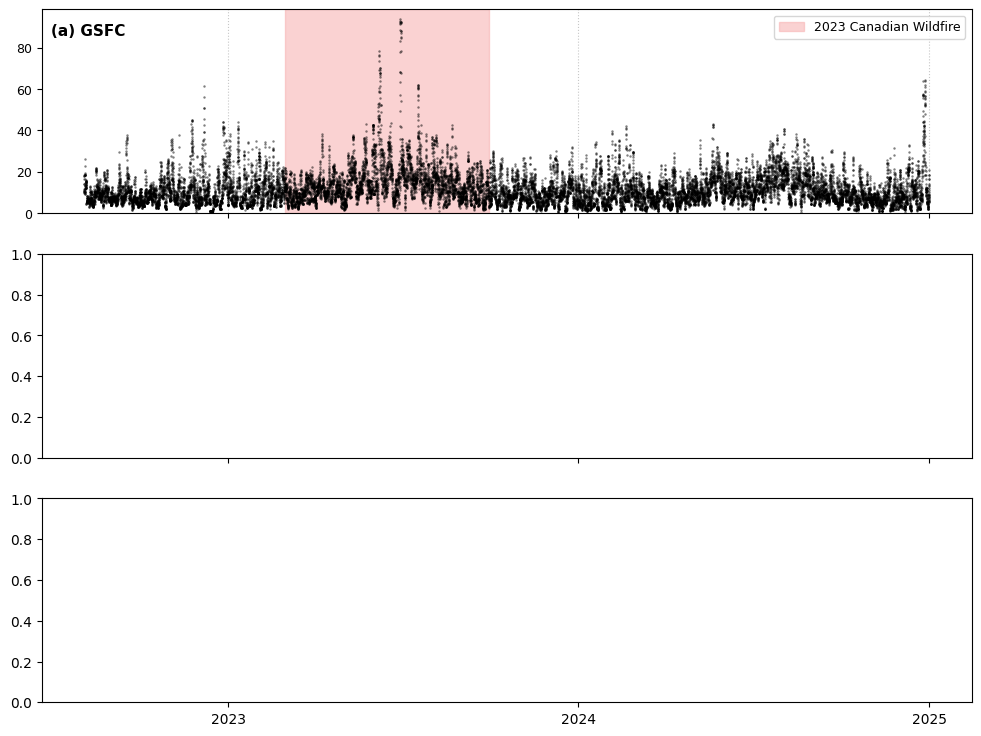

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sites  = ["GSFC", "HU_IRB", "SERC"]
labels = ["(a)", "(b)", "(c)"]

highlight_start = pd.Timestamp("2023-03-01")
highlight_end   = pd.Timestamp("2023-09-30")


fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, sharey=False)

for ax, site, label in zip(axes, sites, labels):
    df = pd.read_csv(f"../data/pm25/{site}_pm25.csv", parse_dates=["datetime"])
    df = df.dropna(subset=["PM2_5"]).sort_values("datetime")
    df = df[df["datetime"].dt.year.between(2021, 2024)]

    ax.axvspan(highlight_start, highlight_end,
               color="#f8b4b4", alpha=0.6, zorder=0, label="2023 Canadian Wildfire")

    ax.scatter(df["datetime"], df["PM2_5"],
               s=3, color="black", alpha=0.5, linewidths=0, zorder=2)

    ax.text(0.01, 0.93, f"{label} {site}", transform=ax.transAxes,
            fontsize=11, fontweight="bold", va="top")

    ax.set_ylim(bottom=0)

    # ---- YEAR TICKS ONLY ----
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # vertical dotted gridline on each year
    ax.grid(axis='x', linestyle=':', linewidth=0.8, alpha=0.7)

    ax.tick_params(axis="x", labelsize=9)
    ax.tick_params(axis="y", labelsize=9)

    if ax == axes[0]:
        ax.legend(loc="upper right", fontsize=9, frameon=True, framealpha=0.8)

fig.text(0.04, 0.5, "PM2.5 (μg/m³)", va="center", rotation="vertical", fontsize=11)

plt.tight_layout(h_pad=0.4)
plt.subplots_adjust(left=0.1)

plt.savefig("../data/PM25_time_series.png", dpi=300, bbox_inches="tight")
plt.show()